<a href="https://colab.research.google.com/github/Shrutika2026/Sqrock-DataScience-Week4/blob/main/DataScience_Week4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas numpy matplotlib seaborn scikit-learn

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
df = pd.read_csv("/content/train.csv")

In [ ]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [ ]:
df.dropna(inplace=True)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df['Order Date'] = pd.to_datetime(
    df['Order Date'],
    dayfirst=True
)

In [ ]:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Day'] = df['Order Date'].dt.day
df['DayOfWeek'] = df['Order Date'].dt.dayofweek

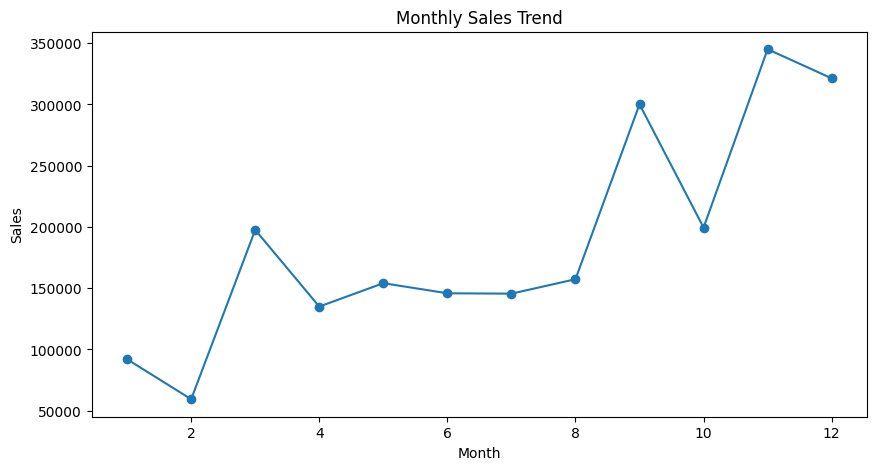

In [ ]:
monthly_sales = df.groupby('Month')['Sales'].sum()

plt.figure(figsize=(10,5))
monthly_sales.plot(kind='line', marker='o')

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.show()

In [ ]:
df['Month'] = df['Order Date'].dt.month

In [ ]:
print(df.columns)

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Year', 'Month', 'Day', 'DayOfWeek'],
      dtype='object')


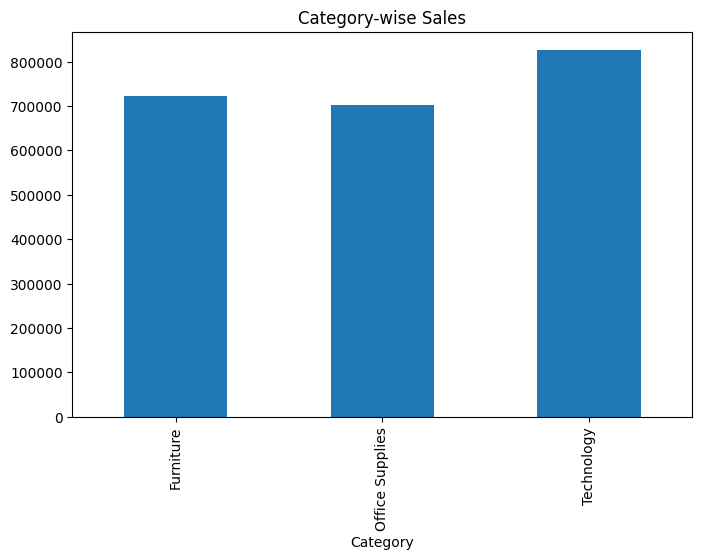

In [ ]:
category_sales = df.groupby('Category')['Sales'].sum()

plt.figure(figsize=(8,5))
category_sales.plot(kind='bar')

plt.title("Category-wise Sales")

plt.show()

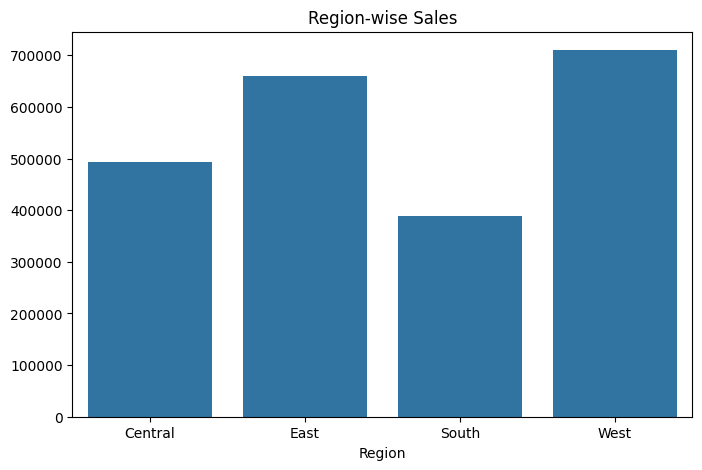

In [ ]:
region_sales = df.groupby('Region')['Sales'].sum()

plt.figure(figsize=(8,5))

sns.barplot(
    x=region_sales.index,
    y=region_sales.values
)

plt.title("Region-wise Sales")

plt.show()

In [ ]:
print(df.columns)

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Year', 'Month', 'Day', 'DayOfWeek'],
      dtype='object')


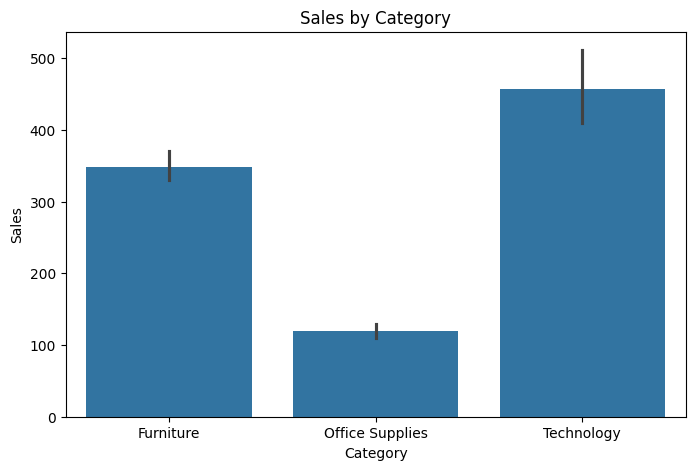

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Category',
    y='Sales',
    data=df
)

plt.title("Sales by Category")

plt.show()

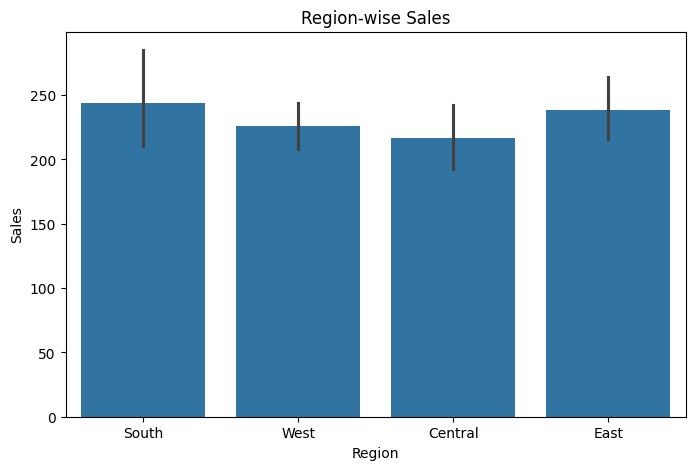

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Region',
    y='Sales',
    data=df
)

plt.title("Region-wise Sales")

plt.show()

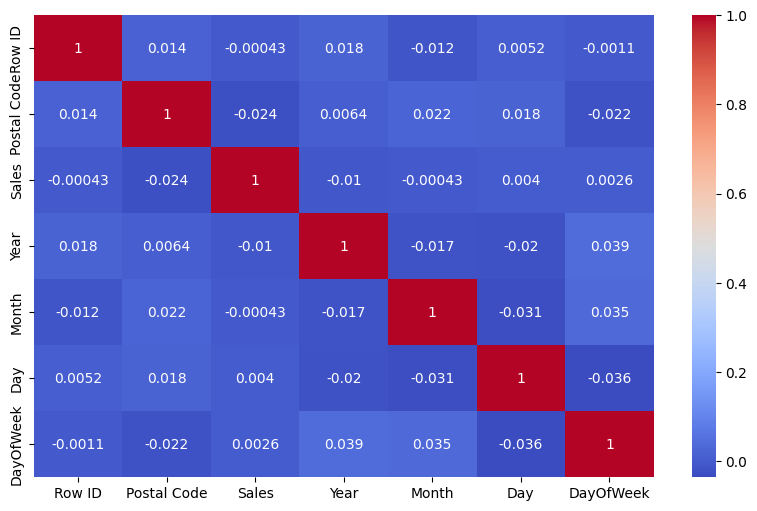

In [ ]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.show()

In [ ]:
le = LabelEncoder()

df['Category'] = le.fit_transform(df['Category'])
df['Region'] = le.fit_transform(df['Region'])

In [ ]:
X = df[['Year', 'Month', 'Day', 'DayOfWeek', 'Category']]
y = df['Sales']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
mae = mean_absolute_error(y_test, y_pred)

print("MAE:", mae)

MAE: 286.5680866501173


In [ ]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("RMSE:", rmse)

RMSE: 699.0906319342713


In [ ]:
r2 = r2_score(y_test, y_pred)

print("R2 Score:", r2)

R2 Score: 0.0008300781815137048


In [ ]:
future_data = pd.DataFrame({
    'Year': [2026],
    'Month': [6],
    'Day': [15],
    'DayOfWeek': [2],
    'Category': [1]
})

future_prediction = model.predict(future_data)

print("Predicted Sales:", future_prediction)

Predicted Sales: [146.37214725]


In [ ]:
from sklearn.ensemble import RandomForestRegressor

In [ ]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
rf_pred = rf_model.predict(X_test)

In [ ]:
rf_mae = mean_absolute_error(y_test, rf_pred)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Results")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R2 Score:", rf_r2)

Random Forest Results
MAE: 288.3214809133403
RMSE: 735.0938286853025
R2 Score: -0.10473455997656167


In [ ]:
!pip install xgboost

In [ ]:
from xgboost import XGBRegressor

In [ ]:
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
xgb_pred = xgb_model.predict(X_test)

In [ ]:
xgb_mae = mean_absolute_error(y_test, xgb_pred)

xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))

xgb_r2 = r2_score(y_test, xgb_pred)

print("XGBoost Results")
print("MAE:", xgb_mae)
print("RMSE:", xgb_rmse)
print("R2 Score:", xgb_r2)

XGBoost Results
MAE: 269.59673402097627
RMSE: 694.3236548985076
R2 Score: 0.014409951101886032


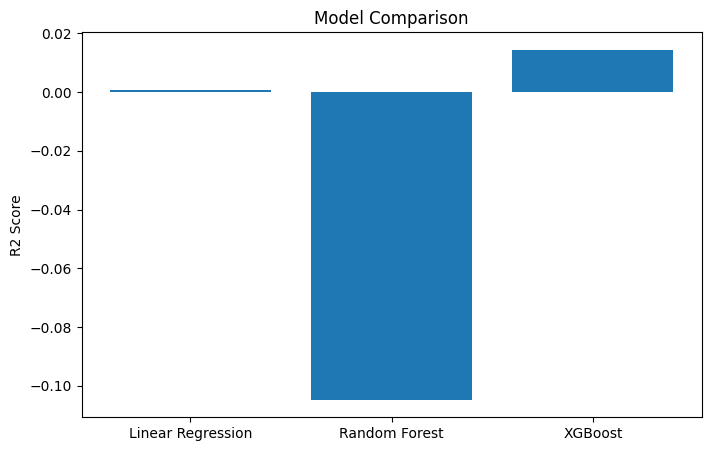

In [ ]:
models = ['Linear Regression', 'Random Forest', 'XGBoost']

r2_scores = [
    r2,
    rf_r2,
    xgb_r2
]

plt.figure(figsize=(8,5))

plt.bar(models, r2_scores)

plt.title("Model Comparison")

plt.ylabel("R2 Score")

plt.show()

In [ ]:
future_months = pd.DataFrame({
    'Year': [2026]*12,
    'Month': list(range(1,13)),
    'Day': [1]*12,
    'DayOfWeek': [0]*12,
    'Category': [1]*12
})

In [ ]:
future_sales = rf_model.predict(future_months)

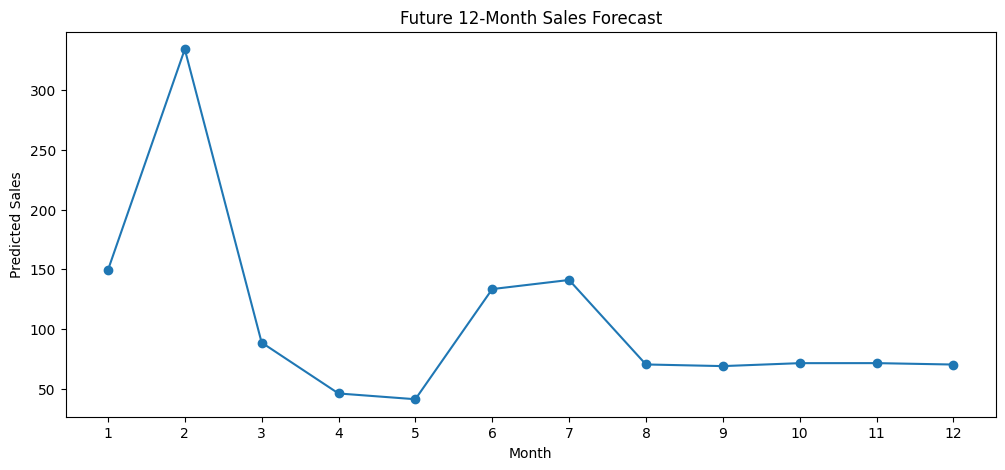

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(
    range(1,13),
    future_sales,
    marker='o'
)

plt.title("Future 12-Month Sales Forecast")

plt.xlabel("Month")

plt.ylabel("Predicted Sales")

plt.xticks(range(1,13))

plt.show()

In [ ]:
!pip install plotly

In [ ]:
import plotly.express as px

monthly_sales = df.groupby('Month')['Sales'].sum().reset_index()

fig = px.line(
    monthly_sales,
    x='Month',
    y='Sales',
    title='Interactive Monthly Sales Trend'
)

fig.show()

In [ ]:
best_category = df.groupby('Category')['Sales'].sum().idxmax()

best_region = df.groupby('Region')['Sales'].sum().idxmax()

print("Business Recommendations")
print("------------------------")
print(f"Focus more on Category: {best_category}")
print(f"Highest performing Region: {best_region}")
print("Increase marketing during holiday season.")
print("Maintain stock for high-selling products.")

Business Recommendations
------------------------
Focus more on Category: 2
Highest performing Region: 3
Increase marketing during holiday season.
Maintain stock for high-selling products.


In [ ]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 102.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 105.6 MB/s eta 0:00:00


In [ ]:
%%writefile app.py

import streamlit as st
import pandas as pd
import plotly.express as px

df = pd.read_csv("SampleSuperstore.csv")

st.title("Sales Forecasting Dashboard")

st.subheader("Dataset")
st.write(df.head())

monthly_sales = df.groupby('Category')['Sales'].sum().reset_index()

fig = px.bar(
    monthly_sales,
    x='Category',
    y='Sales',
    title='Category Sales'
)

st.plotly_chart(fig)

Writing app.py


In [ ]:
!streamlit run app.py & npx localtunnel --port 8501

⠙⠹

⠸⠼⠴Need to install the following packages:
localtunnel@2.0.2
Ok to proceed? (y) 2026-05-26 12:51:05.145 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.197.146.220:8501

